# Configuration et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Configuration Kaggle
INPUT_PATH = '/kaggle/input/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv' 
OUTPUT_PATH = '/kaggle/working/'

# Chargement
df = pd.read_csv(INPUT_PATH)

# Analyse exploratoire (EDA)

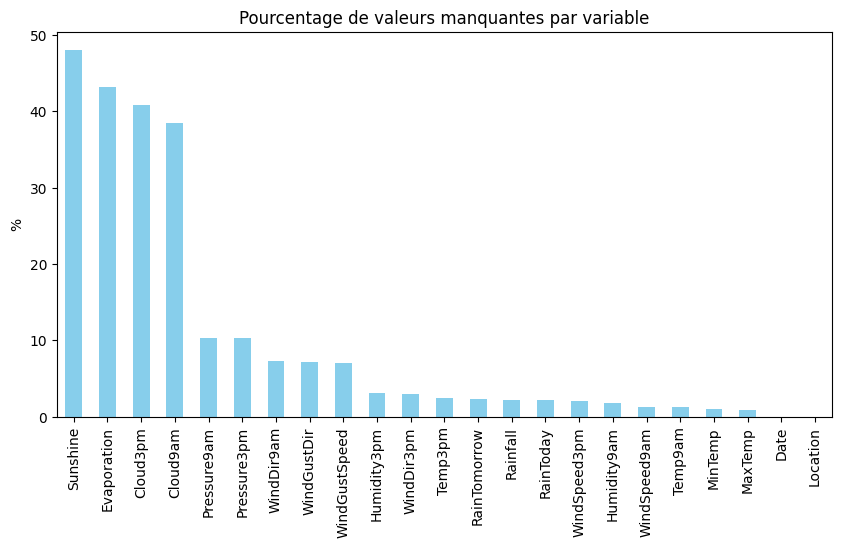

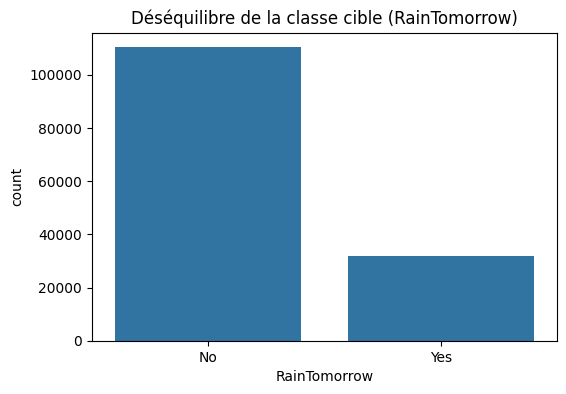

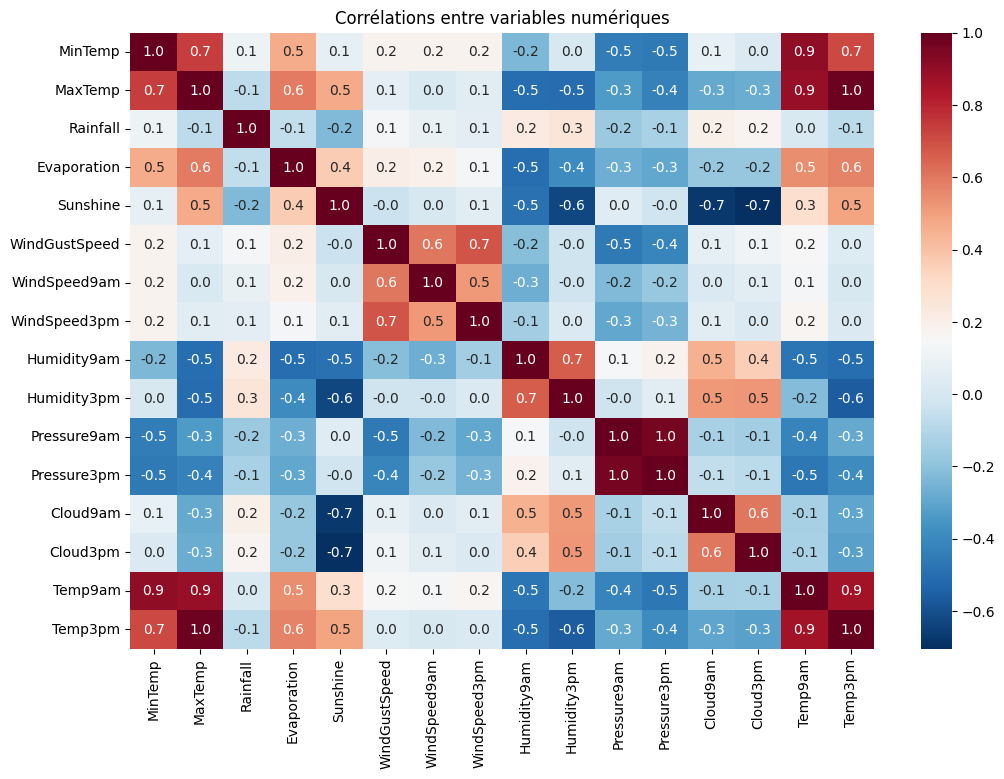

In [2]:
# Taux de complétion
plt.figure(figsize=(10, 5))
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing.plot(kind='bar', color='skyblue')
plt.title('Pourcentage de valeurs manquantes par variable')
plt.ylabel('%')
plt.show()

# Analyse de la cible (Indispensable pour justifier les futures métriques) 
plt.figure(figsize=(6, 4))
sns.countplot(x='RainTomorrow', data=df)
plt.title('Déséquilibre de la classe cible (RainTomorrow)')
plt.show()

# Matrice de corrélation pour la colinéarité 
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".1f", cmap='RdBu_r')
plt.title('Corrélations entre variables numériques')
plt.show()

# Feature Engineering

In [3]:
def expert_preprocessing(df_input):
    df_c = df_input.copy()
    
    # Gestion de la Date : Transformation cyclique (Sin/Cos)
    df_c['Date'] = pd.to_datetime(df_c['Date'])
    df_c['Month_sin'] = np.sin(2 * np.pi * df_c['Date'].dt.month / 12)
    df_c['Month_cos'] = np.cos(2 * np.pi * df_c['Date'].dt.month / 12)
    
    # Création d'interactions météo logiques
    if 'Pressure3pm' in df_c.columns and 'Pressure9am' in df_c.columns:
        df_c['Pressure_Diff'] = df_c['Pressure3pm'] - df_c['Pressure9am']
        
    if 'MaxTemp' in df_c.columns and 'MinTemp' in df_c.columns:
        df_c['Amplitude_Temperature'] = df_c['MaxTemp'] - df_c['MinTemp']
        
    if 'Humidity3pm' in df_c.columns and 'Humidity9am' in df_c.columns:
        df_c['Evolution_Humidity'] = df_c['Humidity3pm'] - df_c['Humidity9am']
    
    # Suppression des colonnes inutiles ou redondantes
    df_c = df_c.drop(['Date'], axis=1)
    return df_c

df_processed = expert_preprocessing(df)

# Nettoyage et transformation

In [4]:
df_processed = df_processed.dropna(subset=['RainTomorrow'])
X = df_processed.drop('RainTomorrow', axis=1)
y = df_processed['RainTomorrow'].map({'No': 0, 'Yes': 1}) # Encodage binaire

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identification des colonnes
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


# Imputation
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# Mise à l'échelle (Scaling)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Encodage Catégoriel (Dummies)
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alignement final pour s'assurer que train et test ont les mêmes colonnes
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Sauvegarde

In [5]:
# Sauvegarde des objets de transformation
assets = {
    'scaler': scaler,
    'num_imputer': num_imputer,
    'cat_imputer': cat_imputer,
    'final_columns': X_train.columns.tolist()
}
joblib.dump(assets, os.path.join(OUTPUT_PATH, 'rain_assets.joblib'))

# Sauvegarde des données prêtes pour les modèles
X_train.to_csv(os.path.join(OUTPUT_PATH, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(OUTPUT_PATH, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(OUTPUT_PATH, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(OUTPUT_PATH, 'y_test.csv'), index=False)

print("Preprocessing terminé. Fichiers enregistrés dans /kaggle/working/")

Preprocessing terminé. Fichiers enregistrés dans /kaggle/working/


**MODE D'EMPLOI DONNEES**

* X_train.csv : Les variables explicatives pour l'entraînement (nettoyées et standardisées).
* y_train.csv : La variable cible (RainTomorrow) pour l'entraînement.
* X_test.csv : Les variables explicatives pour le test (à ne jamais utiliser pour l'entraînement !).
* y_test.csv : La vraie cible du jeu de test pour calculer vos scores.
* rain_assets.joblib : Un dictionnaire contenant les outils de transformation (utile plus tard pour l'interprétabilité des colonnes).
